# Syria FireWatch v2: predicting dangerous fire days from daily weather
Based on the team's first notebook, with these changes:
  1. location (lat/lon) is now a feature
  2. a "placebo" baseline: season + location only, NO weather
  3. outputs are called "score" (not probability); the risk table is the headline
  4. softer advice text, filled with the REAL observed fire rates
  5. target = fire_day_major (dangerous fire day); change TARGET to compare
  6. fire season only (May-Oct)
  7. season as a "clock" (sin/cos) instead of month 1..12
  8. three periods: train <= 2019, validation 2020-21 (thresholds), test 2022+ (final exam)

## 1. Setup

Load the tools and set the choices you can change (target, season, years). Change `TARGET` to `fire_day_any` to compare the two definitions.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, PrecisionRecallDisplay)

# ---- Settings you can change ------------------------------------------------
DATA_PATH     = "daily_table_fixed.csv"
TARGET        = "fire_day_major"      # or "fire_day_any"
SEASON        = (5, 10)               # May..October
TRAIN_END     = 2019                  # train: <= 2019
VALID_END     = 2021                  # validation: 2020-2021, test: >= 2022
USE_LOCATION  = True
RANDOM_STATE  = 42
# -----------------------------------------------------------------------------
os.makedirs("figures", exist_ok=True)

## 2. Load, clean dates, keep fire season

Read the table, fix the date format (also handles files re-saved by Excel), and keep May to October only.

In [2]:
df = pd.read_csv(DATA_PATH)
try:                                                   # normal ISO dates: 2012-01-20
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
except ValueError:                                     # file was re-saved by Excel: 20-01-12
    df["date"] = pd.to_datetime(df["date"], format="%d-%m-%y")

df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df = df[df["month"].between(*SEASON)].sort_values(["cell", "date"]).reset_index(drop=True)

print("Shape (fire season only):", df.shape)
print("Dates:", df["date"].min().date(), "->", df["date"].max().date())
print("Cells:", df["cell"].nunique())
print(f"Share of days with {TARGET} = 1: {df[TARGET].mean():.1%}")

Shape (fire season only): (18459, 19)
Dates: 2012-05-01 -> 2026-06-30
Cells: 7
Share of days with fire_day_major = 1: 11.3%


## 3. Features

The model's inputs (X). Season becomes a *clock* (sin/cos) so December and January are neighbours. Fire columns are never allowed as inputs.

In [3]:
# Season as a clock: day 1 and day 365 are neighbours, the summer peak is learnable.
doy = df["date"].dt.dayofyear
df["season_sin"] = np.sin(2 * np.pi * doy / 365)
df["season_cos"] = np.cos(2 * np.pi * doy / 365)

WEATHER  = ["t2m_max", "rh2m", "ws2m", "prectotcorr",
            "dry_days", "rh2m_3d", "t2m_max_3d", "rain_7d"]
SEASON_F = ["season_sin", "season_cos"]
LOCATION = ["lat", "lon"] if USE_LOCATION else []

FEATURES = WEATHER + SEASON_F + LOCATION
PLACEBO  = SEASON_F + LOCATION           # "where + when" only, no weather

# Fire columns are the OUTCOME: never allowed as inputs (data leakage).
assert not any(c.startswith("fire") or c.endswith("frp") for c in FEATURES)
print("Features:", FEATURES)

Features: ['t2m_max', 'rh2m', 'ws2m', 'prectotcorr', 'dry_days', 'rh2m_3d', 't2m_max_3d', 'rain_7d', 'season_sin', 'season_cos', 'lat', 'lon']


## 4. Time-based split: train / validation / test

Study on the past (train), tune on 2020-21 (validation), final exam on 2022+ (test).

In [4]:
train = df[df["year"] <= TRAIN_END]
valid = df[df["year"].between(TRAIN_END + 1, VALID_END)]
test  = df[df["year"] > VALID_END]

y_train, y_valid, y_test = train[TARGET], valid[TARGET], test[TARGET]
for name, d in [("Train", train), ("Valid", valid), ("Test ", test)]:
    print(f"{name}: {len(d):>6,} rows ({d['year'].min()}-{d['year'].max()}), "
          f"fire rate {d[TARGET].mean():.1%}")
BASE_RATE = y_test.mean()                # what random guessing scores in PR-AUC

Train: 10,304 rows (2012-2019), fire rate 13.9%
Valid:  2,576 rows (2020-2021), fire rate 11.6%
Test :  5,579 rows (2022-2026), fire rate 6.5%


## 5. Helpers

`best_f1_threshold` picks the cut-off on validation data. `run_model` trains a model, tunes it on validation, and scores it once on the test years.

In [5]:
def best_f1_threshold(y, p):
    """Cut-off with the best F1, chosen on VALIDATION data only."""
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    return float(thr[np.argmax(f1)])

results = []
def run_model(name, model, feats):
    model.fit(train[feats], y_train)                         # study: train years only
    p_valid = model.predict_proba(valid[feats])[:, 1]
    thr = best_f1_threshold(y_valid, p_valid)                # tune on validation
    p_test = model.predict_proba(test[feats])[:, 1]          # final exam: test years
    pred = (p_test >= thr).astype(int)
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, p_test),
        "pr_auc": average_precision_score(y_test, p_test),
        "lift_vs_random": average_precision_score(y_test, p_test) / BASE_RATE,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })
    return model, p_valid, p_test

def make_logreg():
    return make_pipeline(StandardScaler(),
                         LogisticRegression(class_weight="balanced", max_iter=2000,
                                            random_state=RANDOM_STATE))

def make_rf():
    return RandomForestClassifier(n_estimators=300, min_samples_leaf=10,
                                  class_weight="balanced_subsample",
                                  n_jobs=-1, random_state=RANDOM_STATE)

## 6. Baselines (no weather) and models

The rule and the **placebo** (season + location only, no weather) are what the weather models must beat.

In [6]:
# A. Hand-made rule: hot AND dry day
rule_pred = ((test["t2m_max"] >= 33) & (test["rh2m"] <= 55)).astype(int)
results.append({"model": "Rule (T>=33 & RH<=55)", "roc_auc": np.nan, "pr_auc": np.nan,
                "lift_vs_random": np.nan,
                "precision": precision_score(y_test, rule_pred, zero_division=0),
                "recall": recall_score(y_test, rule_pred),
                "f1": f1_score(y_test, rule_pred)})

# B. The PLACEBO: only season + location, no weather
placebo, _, p_placebo = run_model("Placebo: season+location only", make_rf(), PLACEBO)

# C. Weather + season + location
lr, _, p_lr = run_model("Logistic Regression", make_logreg(), FEATURES)
rf, p_valid_rf, p_test_rf = run_model("Random Forest", make_rf(), FEATURES)

# D. Weather only, no season or location (shows how weak weather alone is)
run_model("Random Forest, weather only", make_rf(), WEATHER)

(RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=10,
                        n_estimators=300, n_jobs=-1, random_state=42),
 array([0.13174033, 0.03167684, 0.14188982, ..., 0.07550469, 0.04678763,
        0.05399853]),
 array([0.18998245, 0.09017268, 0.27089579, ..., 0.66272582, 0.65683999,
        0.65268639]))

## 7. Results table

`lift_vs_random` = PR-AUC divided by the random-guess level. The last line shows what weather adds on top of season + location.

In [7]:
results_df = pd.DataFrame(results).set_index("model").round(3)
print(f"\nTest years, target = {TARGET}. Random guess PR-AUC = {BASE_RATE:.3f}")
print(results_df.to_string())
results_df.to_csv("figures/model_results.csv")

gain = results_df.loc["Random Forest", "pr_auc"] - results_df.loc["Placebo: season+location only", "pr_auc"]
print(f"\nWhat weather adds on top of season+location (PR-AUC): {gain:+.3f}")


Test years, target = fire_day_major. Random guess PR-AUC = 0.065
                               roc_auc  pr_auc  lift_vs_random  precision  recall     f1
model                                                                                   
Rule (T>=33 & RH<=55)              NaN     NaN             NaN      0.135   0.321  0.190
Placebo: season+location only    0.805   0.313           4.835      0.198   0.590  0.296
Logistic Regression              0.723   0.173           2.671      0.125   0.632  0.209
Random Forest                    0.846   0.286           4.415      0.233   0.587  0.334
Random Forest, weather only      0.755   0.145           2.243      0.139   0.623  0.227

What weather adds on top of season+location (PR-AUC): -0.027


## 8. Risk levels: Low / Moderate / High (thresholds from VALIDATION only)

Convert scores into three levels, then check the **real** fire rate per level on the test years. This table is the headline result.

In [8]:
HIGH_THR = best_f1_threshold(y_valid, p_valid_rf)
prec, rec, thr = precision_recall_curve(y_valid, p_valid_rf)
ok = thr[rec[:-1] >= 0.80]                       # highest cut-off that still catches >=80%
MOD_THR = float(ok.max()) if len(ok) else HIGH_THR / 2
if MOD_THR >= HIGH_THR:
    MOD_THR = HIGH_THR / 2
print(f"\nThresholds (score): Moderate >= {MOD_THR:.2f}, High >= {HIGH_THR:.2f}")

def to_level(score):
    if score >= HIGH_THR: return "High"
    if score >= MOD_THR:  return "Moderate"
    return "Low"

test = test.copy()
test["score"] = p_test_rf
test["risk"] = test["score"].apply(to_level)

# THE HEADLINE TABLE: what really happened on days of each level (test years)
tbl = (test.groupby("risk")[TARGET]
           .agg(days="size", fire_days="sum", fire_rate="mean")
           .reindex(["Low", "Moderate", "High"]))
tbl["share_of_all_fire_days"] = tbl["fire_days"] / tbl["fire_days"].sum()
tbl["fire_rate"] = (tbl["fire_rate"] * 100).round(1)
tbl["share_of_all_fire_days"] = (tbl["share_of_all_fire_days"] * 100).round(0)
print("\nREAL fire rate (%) per predicted risk level, test years:")
print(tbl.to_string())
tbl.to_csv("figures/risk_table.csv")


Thresholds (score): Moderate >= 0.37, High >= 0.60

REAL fire rate (%) per predicted risk level, test years:
          days  fire_days  fire_rate  share_of_all_fire_days
risk                                                        
Low       3917         71        1.8                    20.0
Moderate   754         78       10.3                    22.0
High       908        212       23.3                    59.0


## 9. Is it stable year by year? (test years)

Quality per test year. PR-AUC swings because each year has few fire days; 2026 only has May-June.

In [9]:
rows = []
for yr, d in test.groupby("year"):
    if d[TARGET].nunique() < 2:
        continue
    rows.append({"year": yr, "days": len(d), "fire_rate_%": round(d[TARGET].mean() * 100, 1),
                 "roc_auc": round(roc_auc_score(d[TARGET], d["score"]), 3),
                 "pr_auc": round(average_precision_score(d[TARGET], d["score"]), 3)})
print("\nPer test year (2026 only has May-June):")
print(pd.DataFrame(rows).to_string(index=False))


Per test year (2026 only has May-June):
 year  days  fire_rate_%  roc_auc  pr_auc
 2022  1288          4.4    0.846   0.162
 2023  1288          8.5    0.897   0.540
 2024  1288          6.9    0.805   0.227
 2025  1288          7.8    0.814   0.264
 2026   427          1.2    0.939   0.578


## 10. Charts

Precision-recall curves and the real fire rate per risk level.

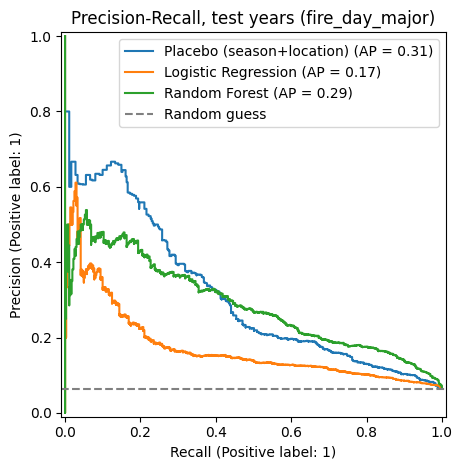

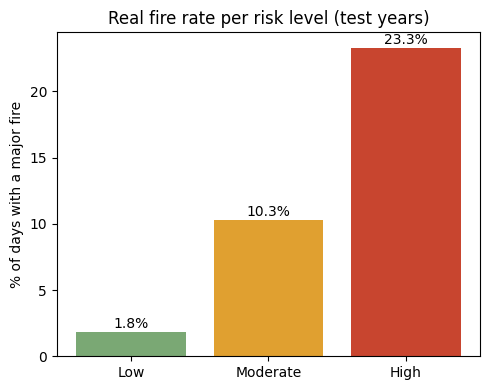

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.8))
PrecisionRecallDisplay.from_predictions(y_test, p_placebo, name="Placebo (season+location)", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, p_lr, name="Logistic Regression", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, p_test_rf, name="Random Forest", ax=ax)
ax.axhline(BASE_RATE, color="grey", ls="--", label="Random guess")
ax.legend(); ax.set_title(f"Precision-Recall, test years ({TARGET})")
plt.tight_layout(); plt.savefig("figures/pr_curves.png", dpi=150); plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#7aa874", "#e0a030", "#c8452f"]
ax.bar(tbl.index, tbl["fire_rate"], color=colors)
for i, v in enumerate(tbl["fire_rate"]):
    ax.text(i, v + 0.3, f"{v}%", ha="center")
ax.set_ylabel("% of days with a major fire"); ax.set_title("Real fire rate per risk level (test years)")
plt.tight_layout(); plt.savefig("figures/risk_levels.png", dpi=150); plt.show()

## 11. Which inputs matter? (permutation importance on test)

Shuffle one input at a time; the bigger the drop, the more the model relied on it. Correlated inputs share credit, so read it as a rough guide.

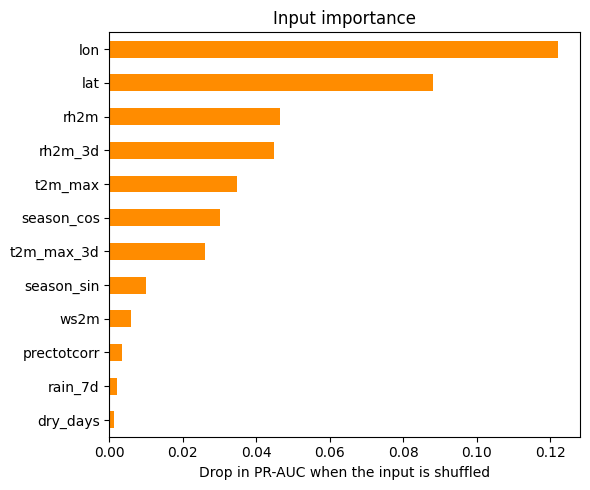


Input importance:
lon            0.1221
lat            0.0882
rh2m           0.0464
rh2m_3d        0.0449
t2m_max        0.0346
season_cos     0.0301
t2m_max_3d     0.0260
season_sin     0.0100
ws2m           0.0057
prectotcorr    0.0033
rain_7d        0.0019
dry_days       0.0013


In [11]:
# Caution: correlated inputs (t2m_max vs t2m_max_3d, lat vs lon) share the credit,
# so each looks smaller than it would alone. Read it as a rough guide.
imp = permutation_importance(rf, test[FEATURES], y_test, scoring="average_precision",
                             n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp_s = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(6, 5))
imp_s.plot.barh(ax=ax, color="darkorange")
ax.set_xlabel("Drop in PR-AUC when the input is shuffled"); ax.set_title("Input importance")
plt.tight_layout(); plt.savefig("figures/feature_importance.png", dpi=150); plt.show()
print("\nInput importance:"); print(imp_s.sort_values(ascending=False).round(4).to_string())

## 12. Alert function

`predict_risk` turns one day of weather at one place into a level and advice. The score is for ranking, not a % chance.

In [12]:
def advice_for(level):
    rate = tbl.loc[level, "fire_rate"]
    texts = {
        "Low":      "Normal conditions. Routine monitoring.",
        "Moderate": "Elevated danger. Avoid open burning and watch conditions.",
        "High":     "High danger. Consider alerting local fire services and restricting open burning.",
    }
    return f"{texts[level]} (In the test years, about {rate:.0f}% of {level} days had a major fire.)"

ADVICE = {lvl: advice_for(lvl) for lvl in ["Low", "Moderate", "High"]}

def predict_risk(date, lat, lon, t2m_max, rh2m, ws2m, prectotcorr, dry_days,
                 rh2m_3d, t2m_max_3d, rain_7d):
    """Risk level + advice for one day at one place. Works for May-Oct only."""
    d = pd.Timestamp(date)
    if not (SEASON[0] <= d.month <= SEASON[1]):
        return {"risk": "n/a", "advice": "Outside the fire-season range the model was trained on."}
    doy_ = d.dayofyear
    row = pd.DataFrame([{
        "t2m_max": t2m_max, "rh2m": rh2m, "ws2m": ws2m, "prectotcorr": prectotcorr,
        "dry_days": dry_days, "rh2m_3d": rh2m_3d, "t2m_max_3d": t2m_max_3d,
        "rain_7d": rain_7d,
        "season_sin": np.sin(2 * np.pi * doy_ / 365),
        "season_cos": np.cos(2 * np.pi * doy_ / 365),
        "lat": lat, "lon": lon,
    }])[FEATURES]
    score = float(rf.predict_proba(row)[0, 1])    # a SCORE for ranking, not a % chance
    level = to_level(score)
    return {"score": round(score, 2), "risk": level, "advice": ADVICE[level]}

## 13. Demo

A hot dry August day at an inland cell vs a mild wet May day at a coastal cell.

In [13]:
if USE_LOCATION:
    inland = df[df["cell"] == "35.5_36.250"].iloc[0]
    coastal = df[df["cell"] == "35.5_35.625"].iloc[0]
    print("\nHot dry August day, inland cell :",
          predict_risk("2025-08-10", inland["lat"], inland["lon"], 37, 40, 2.5, 0, 45, 42, 36, 0))
    print("Mild wet May day, coastal cell  :",
          predict_risk("2025-05-05", coastal["lat"], coastal["lon"], 20, 80, 3.0, 8, 0, 75, 19, 25))


Hot dry August day, inland cell : {'score': 0.9, 'risk': 'High', 'advice': 'High danger. Consider alerting local fire services and restricting open burning. (In the test years, about 23% of High days had a major fire.)'}
Mild wet May day, coastal cell  : {'score': 0.01, 'risk': 'Low', 'advice': 'Normal conditions. Routine monitoring. (In the test years, about 2% of Low days had a major fire.)'}


In [14]:
!pip install -q gradio

In [16]:
# %% 14. Simple interface (Gradio) for the v2 model
# In Colab, run this first in its own cell:  !pip install -q gradio
import gradio as gr

COLORS = {"Low": "#2e7d32", "Moderate": "#f9a825", "High": "#c62828", "n/a": "#757575"}

# location of each grid cell (the model needs lat/lon)
CELLS = df.groupby("cell")[["lat", "lon"]].first()

def risk_card(res):
    """Coloured card showing the model output."""
    score_line = f"<p style='margin:6px 0;font-size:18px'>Risk score: {res['score']:.2f}</p>" if "score" in res else ""
    return (f"<div style='padding:18px;border-radius:12px;text-align:center;"
            f"background:{COLORS[res['risk']]};color:white'>"
            f"<h2 style='margin:0'>{res['risk']} fire risk</h2>{score_line}"
            f"<p style='margin:0'>{res['advice']}</p></div>")

# ---- Tab 1: type in the weather yourself -----------------------------------
def manual_predict(date_str, cell, t2m_max, rh2m, ws2m, prectotcorr,
                   dry_days, t2m_max_3d, rh2m_3d, rain_7d):
    try:
        pd.Timestamp(date_str)
    except Exception:
        return "<p>Please enter the date as YYYY-MM-DD.</p>"
    lat, lon = CELLS.loc[cell, "lat"], CELLS.loc[cell, "lon"]
    res = predict_risk(date_str, lat, lon, t2m_max, rh2m, ws2m, prectotcorr,
                       dry_days, rh2m_3d, t2m_max_3d, rain_7d)
    return risk_card(res)

# ---- Tab 2: pick a real day from the data and compare with what happened ----
def lookup_day(date_str, cell):
    try:
        d = pd.Timestamp(date_str)
    except Exception:
        return "<p>Please enter the date as YYYY-MM-DD.</p>"
    row = df[(df["date"] == d) & (df["cell"] == cell)]
    if row.empty:
        return "<p>No data for that date and cell (the data covers May-October only).</p>"
    r = row.iloc[0]
    res = predict_risk(r["date"], r.lat, r.lon, r.t2m_max, r.rh2m, r.ws2m, r.prectotcorr,
                       r.dry_days, r.rh2m_3d, r.t2m_max_3d, r.rain_7d)
    actual = "Major fire detected" if r[TARGET] == 1 else "No major fire"
    note = ("" if r.year > VALID_END else
            "<p><i>This date was in the training/validation years, so the result is optimistic. "
            "Use 2022 or later for an honest test.</i></p>")
    return (risk_card(res)
            + f"<p style='text-align:center'><b>What actually happened:</b> {actual}</p>" + note)

with gr.Blocks(title="Syria FireWatch") as app:
    gr.Markdown("# 🔥 Syria FireWatch\nEstimate the fire danger of a day (May-October).")

    with gr.Tab("Enter weather"):
        with gr.Row():
            with gr.Column():
                date_m = gr.Textbox(value="2025-08-10", label="Date (YYYY-MM-DD, May-Oct)")
                cell_m = gr.Dropdown(list(CELLS.index), value=list(CELLS.index)[0], label="Grid cell")
                t2m_max = gr.Slider(0, 48, value=35, label="Max temperature today (°C)")
                rh2m = gr.Slider(5, 100, value=45, label="Relative humidity today (%)")
                ws2m = gr.Slider(0, 12, value=2.5, step=0.1, label="Wind speed (m/s)")
            with gr.Column():
                prectotcorr = gr.Slider(0, 60, value=0, label="Rain today (mm)")
                dry_days = gr.Slider(0, 120, value=30, step=1, label="Consecutive dry days (rain < 1 mm)")
                t2m_max_3d = gr.Slider(0, 48, value=34, label="3-day average max temperature (°C)")
                rh2m_3d = gr.Slider(5, 100, value=47, label="3-day average humidity (%)")
                rain_7d = gr.Slider(0, 150, value=0, label="Rain in the last 7 days (mm)")
        go = gr.Button("Check fire risk", variant="primary")
        out1 = gr.HTML()
        go.click(manual_predict,
                 [date_m, cell_m, t2m_max, rh2m, ws2m, prectotcorr,
                  dry_days, t2m_max_3d, rh2m_3d, rain_7d], out1)

    with gr.Tab("Test on a real day"):
        date_in = gr.Textbox(value="2023-08-15", label="Date (YYYY-MM-DD, May-Oct)")
        cell_in = gr.Dropdown(list(CELLS.index), value="35.5_36.250", label="Grid cell")
        go2 = gr.Button("Check this day", variant="primary")
        out2 = gr.HTML()
        go2.click(lookup_day, [date_in, cell_in], out2)

app.launch(share=True)   # share=True gives a public link in Colab


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f285edc33f08f84873.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
